## Ship Signal Analysis


In [ ]:
import os
import numpy as np
import warnings
import tifffile
import cv2

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt


PATH_OUTPUT = os.path.join('output', f'406')
os.makedirs(PATH_OUTPUT, exist_ok=True)

In [ ]:
input_image = cv2.imread("700_ship.png", cv2.IMREAD_GRAYSCALE)


In [11]:
pixel_ship_center = np.array((238, 376))

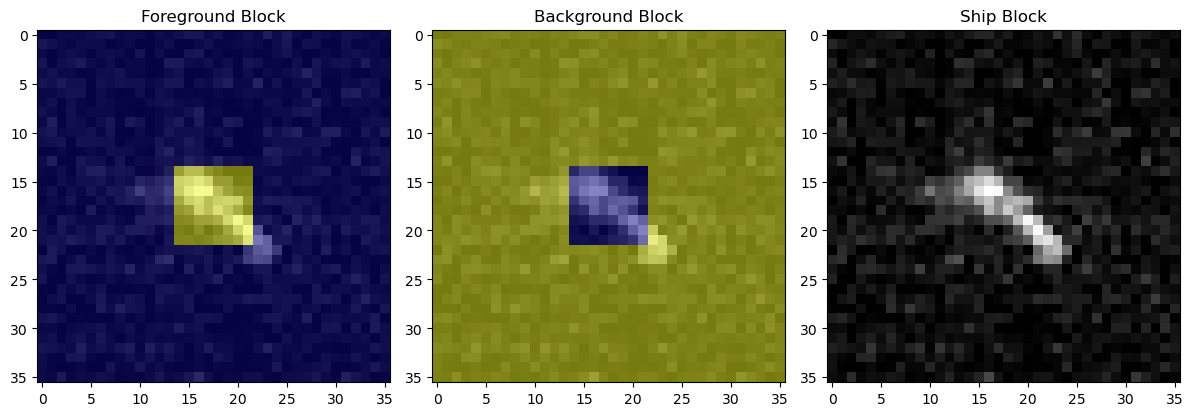

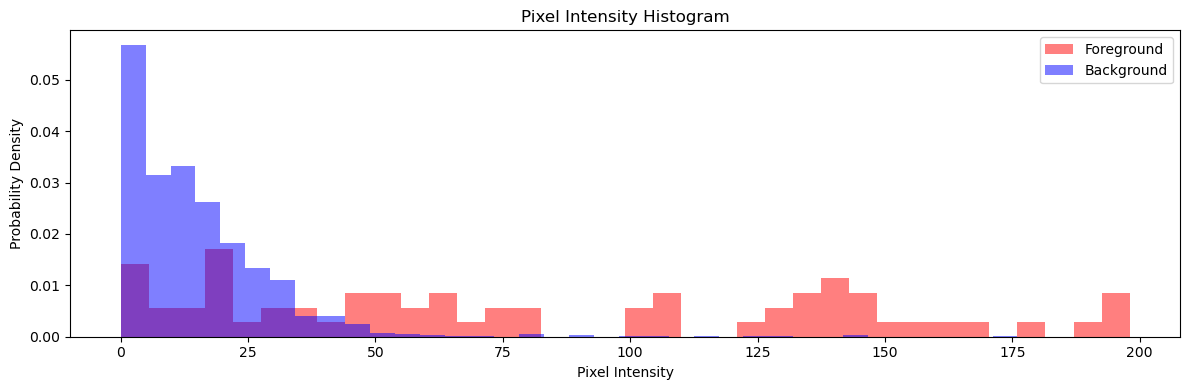

In [12]:
background_size = 36  # 背景領域のサイズ
pixel_size = 8        # ピクセルのブロックサイズ


pixel_block = input_image[
    pixel_ship_center[0]-background_size//2:pixel_ship_center[0]+background_size//2,
    pixel_ship_center[1]-background_size//2:pixel_ship_center[1]+background_size//2,]

mask_foreground = np.zeros_like(pixel_block, dtype='bool')
mask_foreground[
    background_size//2-pixel_size//2:background_size//2+pixel_size//2,
    background_size//2-pixel_size//2:background_size//2+pixel_size//2,] = True

# center the ship in the block
pixel_foreground = pixel_block[mask_foreground]
pixel_background = pixel_block[~mask_foreground]

mask_foreground_img = mask_foreground.astype('uint8') * 255

# plot the blocks
plt.figure(figsize=(12, 5), facecolor='w' , edgecolor='k', dpi=100)
plt.subplot(1, 3, 1)
plt.imshow(pixel_block, cmap='gray')
plt.imshow(mask_foreground_img, cmap='plasma', alpha=0.5)
plt.title('Foreground Block')
plt.subplot(1, 3, 2)
plt.imshow(pixel_block, cmap='gray')
plt.imshow(255 - mask_foreground_img, cmap='plasma', alpha=0.5)
plt.title('Background Block')
plt.subplot(1, 3, 3)
plt.imshow(pixel_block, cmap='gray')
plt.title('Ship Block')
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'cfar_blocks.png'))
plt.show();plt.clf();plt.close()

# plot histogram
plt.figure(figsize=(12, 4), facecolor='w' , edgecolor='k', dpi=100)
plt.hist(pixel_foreground.ravel(), bins=background_size, color='r', alpha=0.5, 
         label='Foreground',density=True)
plt.hist(pixel_background.ravel(), bins=background_size, color='b', alpha=0.5, 
         label='Background',density=True)
plt.legend()
plt.ylabel('Probability Density')
plt.xlabel('Pixel Intensity')
plt.title('Pixel Intensity Histogram')
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'cfar_histogram.png'))
plt.show();plt.clf();plt.close()



In [ ]:
# gaussian fit
from scipy.stats import norm

def gaussian(x, mu, sigma):
    return 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(- (x - mu)**2 / (2 * sigma**2))

def fit_gaussian(data):
    mu, std = norm.fit(data)
    return mu, std

foreground_mu, foreground_std = fit_gaussian(pixel_foreground)
background_mu, background_std = fit_gaussian(pixel_background)

print(f"Foreground: mu={foreground_mu:.2f}, std={foreground_std:.2f}")
print(f"Background: mu={background_mu:.2f}, std={background_std:.2f}")

Foreground: mu=81.45, std=59.74
Background: mu=14.73, std=15.96


In [14]:
threshold_strong, threshold_weak = 4, 3
sum_foreground = np.sum(pixel_foreground)
sum_background = np.sum(pixel_background)

norm_foreground = sum_foreground / len(pixel_foreground)
norm_background = sum_background / len(pixel_background)

print(f"Foreground Norm: {norm_foreground:.2f} | Background Norm: {norm_background:.2f}")

score_strong = threshold_strong * norm_background
score_weak = threshold_weak * norm_background
norm_block = np.mean(pixel_block)

print(f"Check --> Score: {score_strong:.2f} VS Block Norm: {norm_block:.2f}")

Foreground Norm: 81.45 | Background Norm: 14.73
Check --> Score: 58.90 VS Block Norm: 18.02


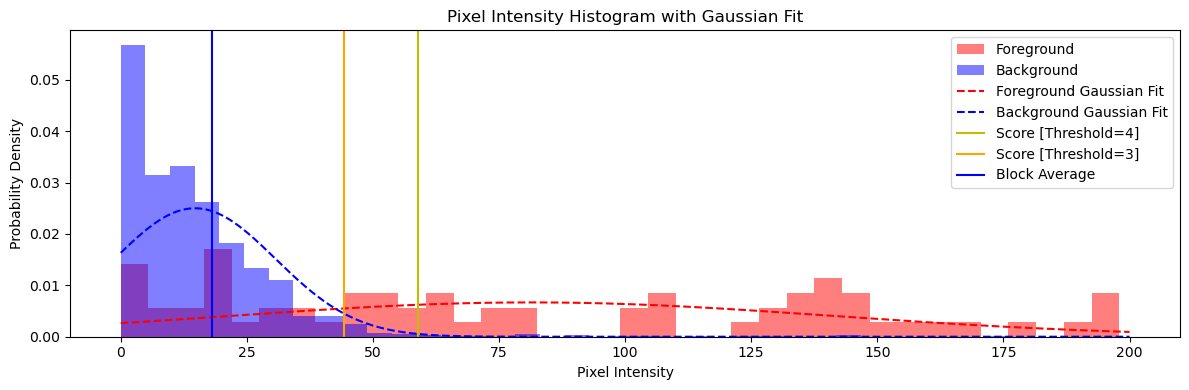

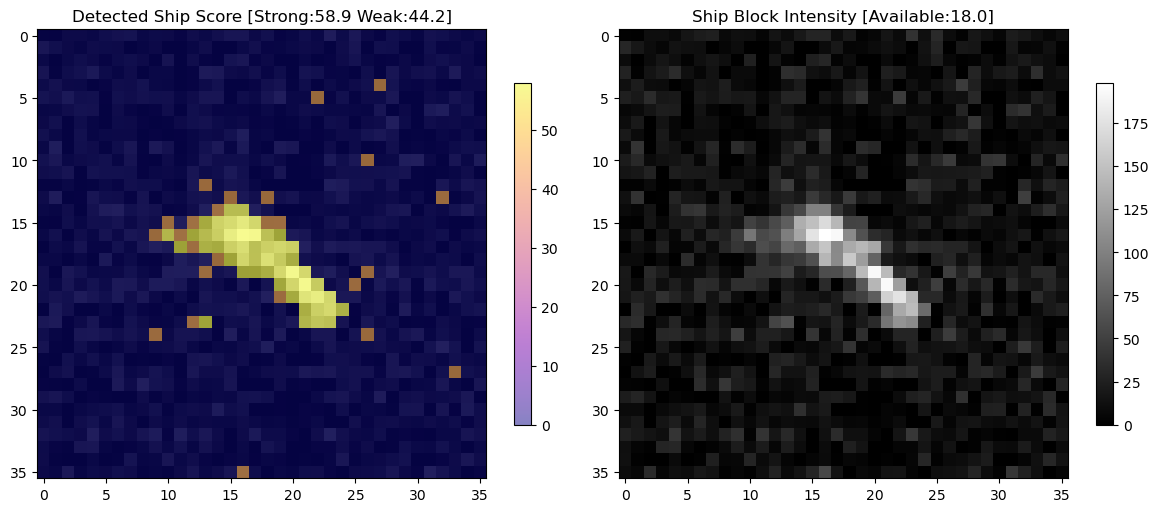

In [ ]:
# plot histogram
plt.figure(figsize=(12, 4), facecolor='w' , edgecolor='k', dpi=100)
plt.hist(pixel_foreground.ravel(), bins=background_size, color='r', alpha=0.5, 
         label='Foreground',density=True)
plt.hist(pixel_background.ravel(), bins=background_size, color='b', alpha=0.5,
            label='Background',density=True)
plt.plot(np.linspace(0, 200, 1000),
         gaussian(np.linspace(0, 200, 1000), foreground_mu, foreground_std),
            color='r', linestyle='--', label='Foreground Gaussian Fit')
plt.plot(np.linspace(0, 200, 1000),
         gaussian(np.linspace(0, 200, 1000), background_mu, background_std),
            color='b', linestyle='--', label='Background Gaussian Fit')
plt.axvline(score_strong, color='y', linestyle='-', label=f'Score [Threshold={threshold_strong}]')
plt.axvline(score_weak, color='orange', linestyle='-', label=f'Score [Threshold={threshold_weak}]')
plt.axvline(norm_block, color='b', linestyle='-', label='Block Average')

plt.legend()
plt.ylabel('Probability Density')
plt.xlabel('Pixel Intensity')
plt.title('Pixel Intensity Histogram with Gaussian Fit')
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'cfar_histogram_fit.png'))
plt.show();plt.clf();plt.close()

is_ship_strong = pixel_block > score_strong
is_ship_weak = pixel_block > score_weak

is_ship = np.zeros_like(pixel_block, dtype=np.uint8)
is_ship[is_ship_weak] = score_weak
is_ship[is_ship_strong] = score_strong

# plot the blocks
plt.figure(figsize=(12, 6), facecolor='w' , edgecolor='k', dpi=100)
plt.subplot(1, 2, 1)
plt.imshow(pixel_block, cmap='gray')
plt.imshow(is_ship, cmap='plasma', alpha=0.5)
plt.colorbar(shrink=0.6)
plt.title(f'Detected Ship Score [Strong:{score_strong:.1f} Weak:{score_weak:.1f}]')
plt.subplot(1, 2, 2)
plt.imshow(pixel_block, cmap='gray')
plt.colorbar(shrink=0.6)
plt.title(f'Ship Block Intensity [Available:{norm_block:.1f}]')
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'cfar_detected_ship.png'))
plt.show();plt.clf();plt.close()
